# Project Motivation

**Task** - the task is a to approximate a smooth non-linear function on a bounded 2D domain

Essentially this is a supervised regression task

As this project is for learning purposes rather pure practicality, we will be using a neural network even though there are more efficient methods of function interpolation.

### Why, can we use a neural network?
-- NEED TO ADD THAT WE CAN DO THIS USING UAT


Before we look at model architecture, training and so on, let's take a look at the data.

## Data Generation

For this project we will create synthetic data.
Here is the methodology :

We have some known smooth and non-linear function $f : [a,b]^2 \to \mathbb{R} , f(x,y)$   
where $a,b\in\mathbb{R}$

To generate the dataset, we take $n$ points $(x,y)\in[a,b]^2$
Then, we evaluate the function at these points and add some noise  
This gives us : $z_{i} = f(x_{i},y_{i}) + \epsilon_{i}\;\;1\leq i\leq n$ where $\epsilon_{i}\sim N(0,\sigma^2)\;\;i.d.d$  
This gives us the final dataset $\mathbf{D}=\{(x_{i} , y_{i} , z_{i}) \}_{i=1}^n$

This is implemented in the code below

So now we have our dataset $\mathbf{D}$, we can begin to think about the model and its implementation.

We need to : 

1) Choose a model
2) Choose a loss function
3) Choose weights that makes F a close approximation of the target function

#### (1) Choosing a model
We have already decided to use a neural network but we need to think about its structure.
For now, we will consider a simple Feed-Forward Network.

##### Feed-Forward Neural Network
<img src="fnn_diagram.png" alt="Feed-Forward Neural Network Diagram"/>

I have drawn this graph to show the general structure of an FNN.

An FNN simply consists of a set of "neurons" or "nodes" (taking inspiration from neurons in the brain).

These are modelled to be basic units of computation.
Typically, each neuron performs a weighted sum on its inputs and then adds some bias. To allow a network to capture more complex patterns, we then introduce non-linearity by applying a post activation function, giving a final output.
  
We then group a some of these neurons together, forming what we call a "layer".  
Thinking about a network in terms of its layers makes it easier when it comes to implementation.

We then take some these layers to form the network as shown above.  
The input layer just refers to the information we input into the network and does not actually perform any computation.  
The intermediate layers are called "hidden" because a user cannot directly interact with them. They perform most/all of the computation.  
Finally, we have the output layer which again doesn't perform any computation and is just the output of the network.  

How is everything connected?
Generally in an FNN, each neuron passes its output to every node in the next layer. This means that the network is "fully" connected.  
  
In different models, layers might not be sequentially arranged, the network might not be fully connected, and other modifications may be added. Additionally, we can make adjustments to model's architecture to improve the model's performance. 

How do we implement this/represent this mathematically?
  
*for convenience, i will explain everything in real numbers, but we can use different objects and so forth.*  
Representing a neuron:   
Suppose, we have $n$ inputs with the $i^{th}$ input, $x_i\in\mathbb{R}$ having weight $w_i\in\mathbb{R}$.  
We can then represent the weighted sum as $$\sum_{i=1}^{n}w_i x_i$$  
We can then add a bias term $b\in\mathbb{R}$, and then apply some activation function $\sigma:\mathbb{R}\to\mathbb{R}$
This gives us the output of a neuron $y\in\mathbb{R}$ as $$y=\sigma\big(\sum_{i=1}^n w_i x_i + b\big)$$


This is for one neuron, but what if we want to represent many neurons at once?  It would be quite messy to store and manage each neuron individually so we use linear algebra to help represent everything neatly.  
Notice that we can write the weighted sum for the $j^{th}$ node (with the $i^{th}$ input having a weight $w_ji$ for the $j^{th} node$) as $$\sum_{i=1}^n w_jix_i$$

This is actually the $i,j$ entry of some matrix multiplication $A\underline{x}$ where $A\in\mathbb{R}^{m \times n}$ and $\underline{x}\in\mathbb{R}^n$
# COMPLETE EXPLANATION

In [166]:
#Libraries needed

import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
from IPython.display import clear_output

In [167]:
rand = np.random.default_rng(42)

#Defining the values we talked about
a = -10
b = 10
n = 1000

#Our target function f
def f(x,y):
    return x**2


xcoords = rand.uniform(low=a,high=b,size=(n,1))
ycoords = rand.uniform(low=a,high=b,size=(n,1))

zcoords = f(xcoords,ycoords)

dataset = np.concatenate((xcoords,ycoords,zcoords),axis=1)

#formatting coords for input
TestTrainSplit = 0.8
batches = 2
SplitIndex = int(TestTrainSplit*n)
TrainData  = dataset[:SplitIndex]
TestData = dataset[SplitIndex:]

noise = rand.normal(loc=0,scale=0.5,size=(SplitIndex,1))
TrainData[:,-1] = (TrainData[:,-1].reshape(SplitIndex,1) + noise).reshape(SplitIndex)



TrainDataBatches = np.split(TrainData,batches)

#Simple scatter plot for visualisation
fig = px.scatter_3d(TrainData,x=0,y=1,z=2)
fig.show()

In [168]:
def ReLu(x):
    return np.maximum(0,x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def swish(x):
    return x * sigmoid(x)
def MSE(labels,predictions):
    loss = np.sum((predictions - labels)**2)
    loss = loss/predictions.shape[0]
    return loss

def RMSE(labels,predictions):
    loss = MSE(labels,predictions)
    return np.sqrt(loss)


def MinMax(x,min,max):
    return (x-min)/(max-min)

def InvMinMax(x,min,max):
    return  x * (max-min) + min

def normalise(x,mean,var,epsilon=1e-5):
    return (x-mean)/np.sqrt(var+epsilon)

def InvNormalise(x,mean,var,epsilon=1e-5):
    return x * np.sqrt(var + epsilon) + mean

In [169]:
#LayerWidths -> an arr storing the number of neurons in the (k+1)th layer (left to right)
#PostActFuncs -> an arr storing the post-act func of each layer
class network:
    def __init__(self, LayerWidths,PostActivationFuncs,NormalisationType = None):
        self.LayerNum = len(LayerWidths)-1
        self.LayerWidths = LayerWidths
        self.PostActivationFuncs = PostActivationFuncs
        self.layers = []
        self.LayerOutputs = []
        for i in range(1,self.LayerNum+1):
            if(i == self.LayerNum):
                layeri= layer(LayerWidths[i-1],LayerWidths[i],PostActivationFuncs[i],None)
            else:
                layeri= layer(LayerWidths[i-1],LayerWidths[i],PostActivationFuncs[i],NormalisationType)
            self.layers.append(layeri)


    def ForwardPass(self,input):
        self.LayerOutputs.clear()
        for i in range(self.LayerNum):
           input , LayerComputations = self.layers[i].compute(input)
           self.LayerOutputs.append(LayerComputations)

        return input

class layer:
    def __init__(self,InputWidth,width,PostActFunc,NormalisationType = None):
        sigma =  np.sqrt(2/(InputWidth+width))
        self.width = width
        self.PostActFunc = PostActFunc
        self.InputWidth = InputWidth
        self.weights = np.array(rand.normal(0,sigma, size=(width,InputWidth)))
        self.bias = np.array(rand.normal(0,sigma, size=(width,1)))
        #stochatistcally initialise a matrix

        #mini norm
        if NormalisationType == 'batch':
            self.gamma = np.random.rand()
            self.beta = np.random.rand()
            self.NormalisationType = 'batch'
        else:
            self.NormalisationType = None

    def compute(self,input):
        computations = {}
        LinearComputation = self.weights@input + self.bias
        computations["Linear"] = LinearComputation


        PostActComputation = self.PostActFunc(LinearComputation)
        computations["LayerOutput"] = PostActComputation
        return PostActComputation , computations

In [170]:
#formed the netowrk
fnn = network([2,100,100,100,1],[lambda x : x,ReLu,ReLu,ReLu,lambda x : x],None)

In [171]:
def GradDesc(CurrVal,Gradient,LearningRate=0.001):
    LearningRate = LearningRate
    return CurrVal - LearningRate*Gradient

In [172]:
LossValues1 = [[] for i in range(batches)]
LossValues2 = []
epochs = int(100)
LearningRate = 1e-4
RegParam = 0.1
loss = 0


for epoch in range(epochs):

    indexes = np.arange(0,batches)
    np.random.shuffle(indexes)

    for BatchNum in indexes:
        CurrentBatch = TrainDataBatches[BatchNum]
        loss = 0
        predictions = 0

        W4 = fnn.layers[3].weights
        b4 = fnn.layers[3].bias

        W3 = fnn.layers[2].weights
        b3 = fnn.layers[2].bias

        W2 = fnn.layers[1].weights
        b2 = fnn.layers[1].bias

        W1 = fnn.layers[0].weights
        b1 = fnn.layers[0].bias

        dW4 = np.zeros((W4.shape))
        db4 = np.zeros((b4.shape))

        dW3 = np.zeros((W3.shape))
        db3 = np.zeros((b3.shape))

        dW2 = np.zeros((W2.shape))
        db2 = np.zeros((b2.shape))

        dW1 = np.zeros((W1.shape))
        db1 = np.zeros((b1.shape))

        N = CurrentBatch.shape[0]

        predictions = np.apply_along_axis(lambda x: fnn.ForwardPass(x.reshape(2,1)),1,CurrentBatch[:,:-1])
        predictions = predictions.reshape(CurrentBatch[:,-1].shape)
        #DeNormalPred = InvNormalise(predictions,MeanLabel,VarLabel)

        loss = MSE(CurrentBatch[:,-1],predictions) + RegParam * (np.sum(W4**2) + np.sum(W3**2) + np.sum(W2**2) + np.sum(W1**2))
        for i in range(N):
            x = CurrentBatch[i,:-1].reshape(2,1)

            dyhat = 2/N * (predictions[i] - CurrentBatch[i,-1])

            #Layer 4
            a3 = fnn.LayerOutputs[2]["LayerOutput"]
            z3 = fnn.LayerOutputs[2]["Linear"]

            dW4 +=  dyhat * a3.T + RegParam*W4
            db4 += dyhat

            #Layer 3
            a2 = fnn.LayerOutputs[1]["LayerOutput"]
            z2 = fnn.LayerOutputs[1]["Linear"]

            delta3 = (W4.T * dyhat) *  (a3 > 0).astype(float) #(sigmoid(z3) + a3*(1-sigmoid(z3)))

            dW3 += delta3 @ a2.T + RegParam*W3
            db3 += delta3

            #Layer 2
            a1 = fnn.LayerOutputs[0]["LayerOutput"]
            z1 = fnn.LayerOutputs[0]["Linear"]

            delta2 = (W3.T @ delta3) * (a2 > 0).astype(float) #(sigmoid(z2) + a2*(1-sigmoid(z2)))


            dW2 += delta2 @ a1.T + RegParam*W2
            db2 += delta2

            #Layer 1
            delta1 = (W2.T @ delta2) * (a1 > 0).astype(float) #(sigmoid(z1) + a1*(1-sigmoid(z1)))

            dW1 += delta1 @ x.T + RegParam*W1
            db1 += delta1


        fnn.layers[3].bias = GradDesc(b4,db4,LearningRate)
        fnn.layers[3].weights = GradDesc(W4,dW4,LearningRate)


        fnn.layers[2].bias = GradDesc(b3,db3,LearningRate)
        fnn.layers[2].weights = GradDesc(W3,dW3,LearningRate)

        fnn.layers[1].bias = GradDesc(b2,db2,LearningRate)
        fnn.layers[1].weights = GradDesc(W2,dW2,LearningRate)


        fnn.layers[0].bias = GradDesc(b1,db1,LearningRate)
        fnn.layers[0].weights = GradDesc(W1,dW1,LearningRate)

        LossValues1[BatchNum].append(np.sqrt(loss))
        LossValues2.append(np.sqrt(loss))

    print(f"epoch : {epoch}, loss : {loss} ")







epoch : 0, loss : 2166.174536955466 
epoch : 1, loss : 1821.1985288026926 
epoch : 2, loss : 2115.6901478509567 
epoch : 3, loss : 2093.833433955904 
epoch : 4, loss : 2071.9384211020824 
epoch : 5, loss : 2050.458918125277 
epoch : 6, loss : 2028.5940152668816 
epoch : 7, loss : 1701.81440840781 
epoch : 8, loss : 1983.0536949691261 
epoch : 9, loss : 1659.7392669787896 
epoch : 10, loss : 1935.6563403793734 
epoch : 11, loss : 1910.9042188519197 
epoch : 12, loss : 1591.1455827316493 
epoch : 13, loss : 1857.773773884062 
epoch : 14, loss : 1829.3074071592346 
epoch : 15, loss : 1799.3836060602816 
epoch : 16, loss : 1483.5881072872396 
epoch : 17, loss : 1732.591746954745 
epoch : 18, loss : 1695.9840501488177 
epoch : 19, loss : 1657.3747039659706 
epoch : 20, loss : 1616.7522595747862 
epoch : 21, loss : 1573.9791373310952 
epoch : 22, loss : 1269.9343377046778 
epoch : 23, loss : 1229.1235996122714 
epoch : 24, loss : 1435.0430261135857 
epoch : 25, loss : 1386.0043993232935 
epo

In [173]:
for layer in fnn.layers:
    print(f"weight : {layer.weights}")

weight : [[-0.07522984  0.04012545]
 [-0.00556351  0.04376592]
 [ 0.01287986 -0.040003  ]
 [-0.10268038 -0.01457162]
 [ 0.02578246 -0.03514801]
 [-0.03877831 -0.11302334]
 [ 0.03548428  0.03327243]
 [ 0.01706529  0.04122782]
 [ 0.01597877 -0.01202817]
 [-0.00670546 -0.02854919]
 [ 0.09674762  0.00087662]
 [ 0.00236314  0.02393355]
 [-0.06350054  0.09450977]
 [-0.08263284  0.03694773]
 [ 0.0022128   0.02484848]
 [-0.03818159  0.00441423]
 [-0.00346352 -0.02804765]
 [-0.0480004   0.08725383]
 [-0.01561299 -0.03011901]
 [-0.03859833  0.06559929]
 [ 0.01938392  0.02733506]
 [-0.01617691  0.03601736]
 [-0.03865898 -0.01747489]
 [ 0.05382928  0.04102466]
 [-0.0730147  -0.02900857]
 [-0.04111731  0.09014787]
 [-0.12060911  0.02875409]
 [-0.0846939  -0.03133454]
 [-0.02670011 -0.01257819]
 [-0.03353188  0.00045273]
 [-0.04076363 -0.06347028]
 [ 0.01423187  0.03448651]
 [ 0.03222129 -0.09581727]
 [-0.00599705  0.03449228]
 [-0.06769407  0.01712519]
 [-0.06136248  0.10737349]
 [ 0.01182456 -0.09

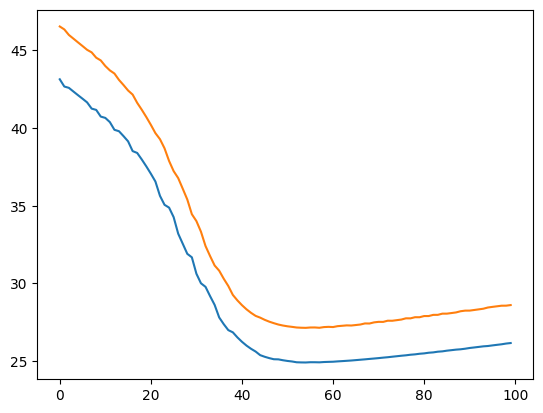

In [174]:
for j in range(len(LossValues1)):
    plt.plot([i for i in range(len(LossValues1[j]))],LossValues1[j])
plt.show()

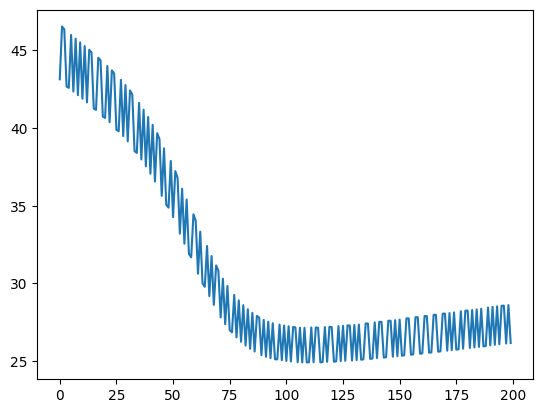

In [175]:
plt.plot(np.arange(0,len(LossValues2)),LossValues2)
plt.show()

In [176]:
def func(x):
    result = fnn.ForwardPass(x[:-1].reshape(2,1))
    print(f"input : {x[:-1]}, prediction : {result}, actual value : {x[-1]}")
    return result
TestPredictions = np.apply_along_axis(func,1,TestData).reshape(200,1)
RMSE(CurrentBatch[:,-1],TestPredictions)

input : [4.77160773 2.20670778], prediction : [[26.10798962]], actual value : 22.76824032086163
input : [-3.65693658  2.47092739], prediction : [[27.23090177]], actual value : 13.37318513112913
input : [ 7.80038914 -7.29840416], prediction : [[31.73468232]], actual value : 60.84607077215278
input : [1.87661096 3.87080939], prediction : [[25.24487846]], actual value : 3.521668697327524
input : [-7.47947317  3.49500713], prediction : [[32.63871782]], actual value : 55.94251882696439
input : [-7.12562677  3.65176244], prediction : [[32.24547566]], actual value : 50.77455687801452
input : [ 3.86190854 -8.51858895], prediction : [[30.30204723]], actual value : 14.914337560465473
input : [-6.54112127 -1.06322315], prediction : [[30.17057565]], actual value : 42.786267484001385
input : [ 0.14585403 -1.81929736], prediction : [[24.26552411]], actual value : 0.021273398545894696
input : [ 9.83548952 -8.26577033], prediction : [[34.61021515]], actual value : 96.73685406998322
input : [-9.9198479

np.float64(573.2601837595577)